## Investigate Medical Appointment Dataset

#### A person makes a doctor's appointment, receives all the instructions, and no-show. Who to blame?

In this notebook we will try to analyze why would some patient not show up for his medical appointment and whether there are reasons for that using the data we have.
We will try to find some correlation between the different attributes we have and whether the patient shows up or not. The dataset we are going to use contains 110.527 medical appointments and its 14 associated variables ( PatientId, AppointmentID, Gender, ScheduledDay, AppointmentDay, Age, Neighbourhood, Scholarship, Hypertension, Diabetes, Alcoholism, Handcap', SMS_received, No-show )

## Objectives

#### Questions to answer
1. What is the percentage of no-show?
2. What factors are important for us to know in order to predict if a patient will show up for their scheduled appointment?
    - Is the time gender related to whether a patient will show or not?
    - Are patients with scholarship more likely to miss their appointment?
    - Are patients who don't recieve sms more likely to miss their appointment?
    - Is the time difference between the scheduling and appointment related to whether a patient will show?
    - Does age affect whether a patient will show up or not?
    - What is the percentage of patients missing their appointments for every neighbourhood

### Solutions

In [3]:
# Disabling the pyforest lib so that I can manually import the required libraries.
import os
os.environ["PYFOREST_DISABLE"] = "1"


In [4]:
# Imporing all the important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
# importing the dataset and viewing the data inside it
df = pd.read_csv("C:/Users/VIVEK/Downloads/med_appointment.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


#### Checking out the data to get an overview

In [4]:
df.shape

(110527, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [8]:
df.describe(include = 'O')

,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


In [9]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

<Axes: >

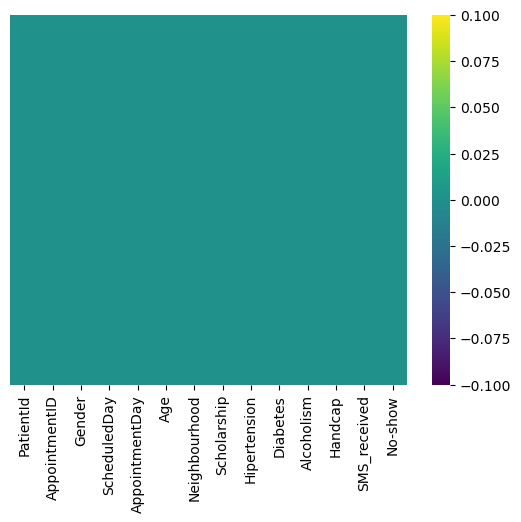

In [10]:
# For visualizing the na values in the dataset
sns.heatmap(df.isna(), yticklabels = False, cbar = True, cmap = 'viridis')

In [11]:
df.duplicated().any()

np.False_

#### Data Wrangling

In [12]:
# Slicing the date part of both the cols
df['ScheduledDay'] = df.ScheduledDay.str.slice(0,10)
df['AppointmentDay'] = df.AppointmentDay.str.slice(0,10)

In [13]:
# Changing the datatype of both the cols to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [14]:
print(df['ScheduledDay'].dtypes)
print(df['AppointmentDay'].dtypes)

datetime64[ns]
datetime64[ns]


In [15]:
# Checking the Age col data to see what all erros do we need to clean
sorted(df.Age.unique())

[np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.i

Text(0.5, 0, 'Age')

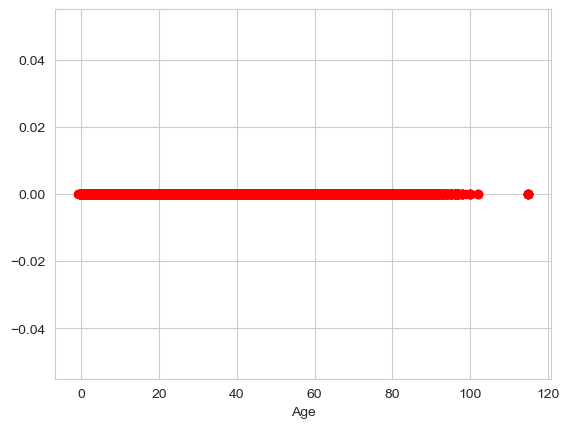

In [16]:
# Visualizing the Age column
sns.set_style('whitegrid')
plt.plot(df['Age'], np.zeros_like(df['Age']), 'ro')
plt.xlabel('Age')

In [17]:
# Replacing the Age col errors with the mean of Age
df.Age = df.Age.replace([-1, 0], df.Age.mean()).astype('int')

In [18]:
# Checking the result
sorted(df.Age.unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.

In [19]:
# Dropping the col which has no relevance to the analysis
df.drop('PatientId', axis = 1, inplace = True)

In [92]:
# Creating a new col to see the no. of day each patient need to wait between scheduling and their appointment day
df['days_until_appointment'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df.days_until_appointment

0          0
1          0
2          0
3          0
4          0
          ..
110522    35
110523    35
110524    41
110525    41
110526    41
Name: days_until_appointment, Length: 110527, dtype: int64

In [7]:
# No Show col is a bit confusing so changing the col name to Show and their values as well for better understanding
df.rename(columns = {'No-show':"Show"}, inplace = True)
df['Show'] = df.Show.map({'No' : 1, 'Yes' : 0}).astype('int')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,1
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,1
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,1
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,1
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,1


In [22]:
df.dtypes

AppointmentID                      int64
Gender                            object
ScheduledDay              datetime64[ns]
AppointmentDay            datetime64[ns]
Age                                int64
Neighbourhood                     object
Scholarship                        int64
Hipertension                       int64
Diabetes                           int64
Alcoholism                         int64
Handcap                            int64
SMS_received                       int64
Show                               int64
days_until_appointment             int64
dtype: object

In [23]:
df.describe()

,AppointmentID,ScheduledDay,AppointmentDay,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Show,days_until_appointment
count,1.105270e+05,110527,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,5.675305e+06,2016-05-08 20:33:18.179630080,2016-05-19 00:57:50.008233472,38.273933,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.798067,10.183702
min,5.030230e+06,2015-11-10 00:00:00,2016-04-29 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.000000
25%,5.640286e+06,2016-04-29 00:00:00,2016-05-09 00:00:00,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,5.680573e+06,2016-05-10 00:00:00,2016-05-18 00:00:00,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000
75%,5.725524e+06,2016-05-20 00:00:00,2016-05-31 00:00:00,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000
max,5.790484e+06,2016-06-08 00:00:00,2016-06-08 00:00:00,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,179.000000
std,7.129575e+04,NaN,NaN,22.104720,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444,15.254996


#### Appointment Column

In [24]:
# Analyzing the appointments per day
appointments_per_day = df.groupby('AppointmentDay', as_index = False).AppointmentID.count().sort_values(
                                by = 'AppointmentDay')

appointments_per_day

,AppointmentDay,AppointmentID
0,2016-04-29,3235
1,2016-05-02,4376
2,2016-05-03,4256
3,2016-05-04,4168
4,2016-05-05,4273
5,2016-05-06,3879
6,2016-05-09,4520
7,2016-05-10,4308
8,2016-05-11,4474
9,2016-05-12,4394


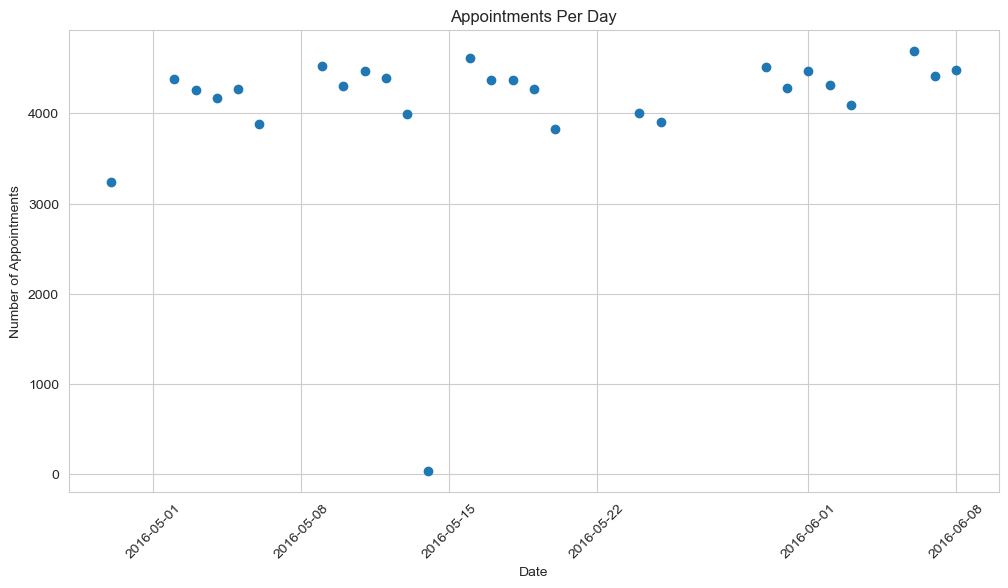

In [25]:
# Visualizing the same for better understanding
sns.set_style('whitegrid')
plt.figure(figsize = (12, 6))
plt.plot(appointments_per_day['AppointmentDay'], appointments_per_day['AppointmentID'], 'o')
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.title("Appointments Per Day")
plt.xticks(rotation = 45)
plt.show()

#### Gender and Show Column

In [26]:
# Grouping the show and gender column to find insights
gender_show_counts = df.groupby(["Show", "Gender"]).Show.count().reset_index(name = 'Count')
gender_show_counts

,Show,Gender,Count
0,0,F,14594
1,0,M,7725
2,1,F,57246
3,1,M,30962


<Axes: xlabel='Show', ylabel='Count'>

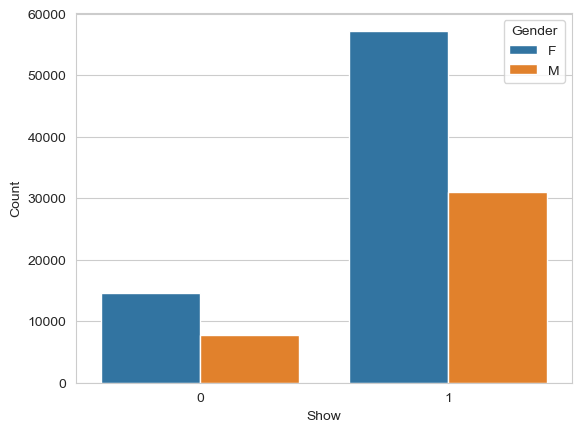

In [27]:
# Visualizing the same for clarity
sns.barplot(data = gender_show_counts, x = 'Show', y = 'Count', hue = 'Gender')

In [14]:
# Counts of Show and No Show
show_count = df.Show.value_counts().reset_index(name = 'Count')
print(show_count)

total = len(df.Show)
print(total)

show_count['Percentage'] = ((show_count['Count'] / show_count['Count'].sum()) * 100).round(2)

print(show_count)

   Show  Count
0     1  88208
1     0  22319
110527
   Show  Count  Percentage
0     1  88208       79.81
1     0  22319       20.19


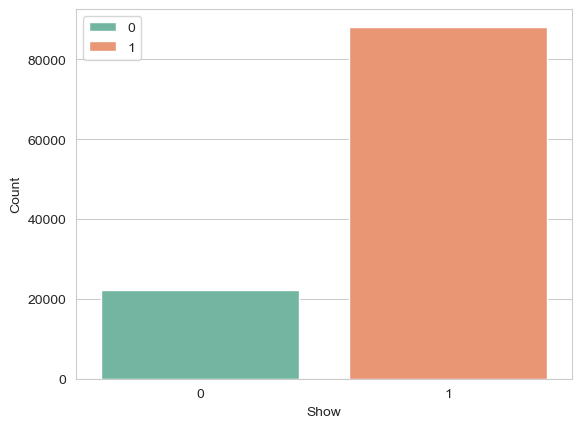

In [29]:
# Visualizing the data to see the no. of people who showed up and those who didn't.
sns.barplot(x = 'Show', y = 'Count', data = show_count, hue = 'Show', palette = 'Set2')
plt.legend()

In [30]:
show_count = df.Show.value_counts().reset_index(name = 'Counts')
total = len(df.Show)

no_show_count = show_count[show_count['Show'] == 0]['Counts'].values[0]
percentage_of_no_show = (no_show_count / total) * 100

print(f"Percentage of No-Shows: {percentage_of_no_show:.2f}%")

Percentage of No-Shows: 20.19%


In [31]:
no_show_gender = df[df.Show == 0]['Gender'].value_counts()
no_show_gender = (no_show_gender*100/total).reset_index()
no_show_gender.columns = ['Gender', 'No_Show_Percentage']
no_show_gender

,Gender,No_Show_Percentage
0,F,13.204013
1,M,6.989242


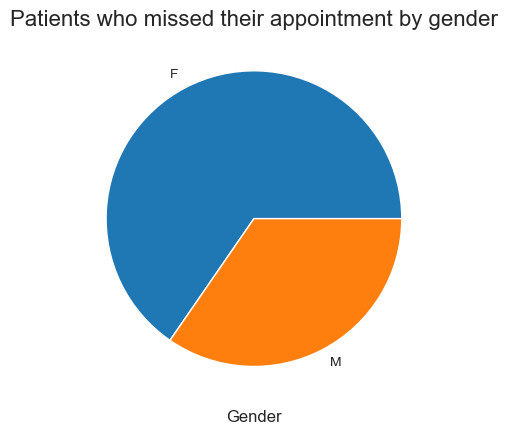

In [32]:
plt.pie(data = no_show_gender, x = 'No_Show_Percentage', labels = 'Gender')
plt.title('Patients who missed their appointment by gender', fontsize = 16)
plt.xlabel("Gender", fontsize = 12)
plt.show()

#### Age and Show Columns

In [33]:
# Getting an overview of the column
df.Age.describe()

count    110527.000000
mean         38.273933
std          22.104720
min           1.000000
25%          20.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [34]:
# Creating categories in Age col
def age_group(age):
    if age < 12:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 35:
        return 'Young Adult'
    elif age < 50:
        return 'Adult'
    elif age < 65:
        return 'Middle Aged'
    else:
        return 'Senior'

df['age_group'] = df.Age.apply(age_group)

age_group
Adult          25405
Young Adult    24246
Middle Aged    22634
Child          16405
Senior         14402
Teen            7435
Name: count, dtype: int64


<Axes: xlabel='age_group', ylabel='Count'>

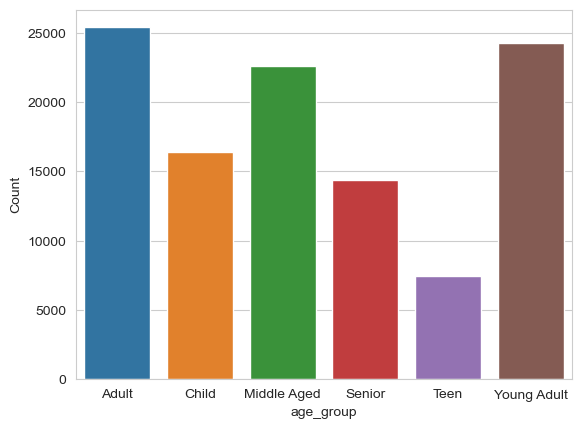

In [35]:
# Grouping the categories and taking out their counts
print(df.age_group.value_counts())
age_cat_counts = df.groupby('age_group').age_group.count().reset_index(name = 'Count')
sns.barplot(data = age_cat_counts, x = 'age_group', y = 'Count', hue = 'age_group')

In [36]:
# Dividing the age_group col into show and no show and taking out their counts
no_show = df.Show == 0
show = df.Show == 1

no_show_age_cat = df[no_show]['age_group'].value_counts().reset_index(name = 'no_show_count').sort_values(by = 'no_show_count', ascending = False)
show_age_cat = df[show]['age_group'].value_counts().reset_index(name = 'show_count').sort_values(by = 'show_count', ascending = False)

print(no_show_age_cat)
print('\n\n\n')
print(show_age_cat)

     age_group  no_show_count
0  Young Adult           5814
1        Adult           5129
2  Middle Aged           3785
3        Child           3396
4       Senior           2233
5         Teen           1962




     age_group  show_count
0        Adult       20276
1  Middle Aged       18849
2  Young Adult       18432
3        Child       13009
4       Senior       12169
5         Teen        5473


In [37]:
no_show_age = df[no_show]['Age'].value_counts(normalize = True).reset_index(name = 'Counts').sort_values(by = 'Counts', ascending = False)
show_age = df[show]['Age'].value_counts(normalize = True).reset_index(name = 'Counts').sort_values(by = 'Counts', ascending = False)

show_age['%age'] = show_age['Counts'] * 100
no_show_age['%age'] = no_show_age['Counts'] * 100

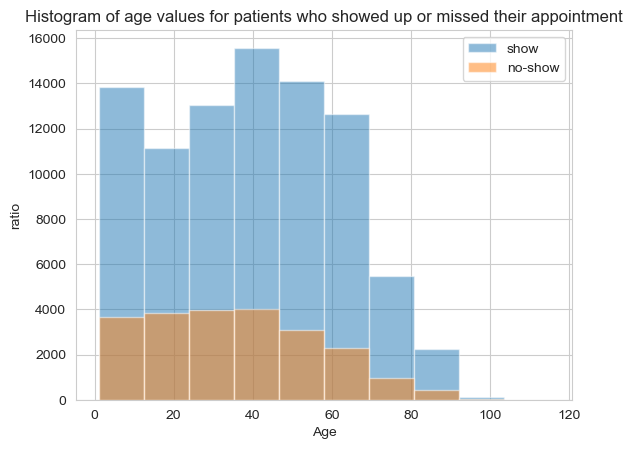

In [38]:
df[show].Age.hist(alpha=0.5,label='show')
df[no_show].Age.hist(alpha=0.5,label='no-show')
plt.xlabel('Age')
plt.ylabel('ratio')
plt.title('Histogram of age values for patients who showed up or missed their appointment')
plt.legend()

   Age    Counts      %age
0   37  0.046674  4.667377
1    1  0.021064  2.106385
2   52  0.016427  1.642708
3   56  0.015554  1.555414
4    2  0.015486  1.548612


Text(0.5, 1.0, 'People showing up as per Age')

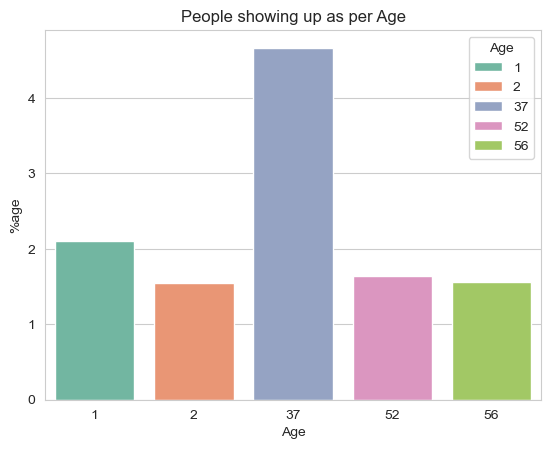

In [39]:
print(show_age.head())
sns.barplot(data = show_age.head(), x = 'Age', y = '%age', hue = 'Age', palette = 'Set2')
plt.title('People showing up as per Age')

   Age    Counts      %age
0   37  0.042833  4.283346
1    1  0.018594  1.859402
2   17  0.017743  1.774273
3   19  0.017653  1.765312
4   30  0.016533  1.653300


Text(0.5, 1.0, 'People not showing up as per Age')

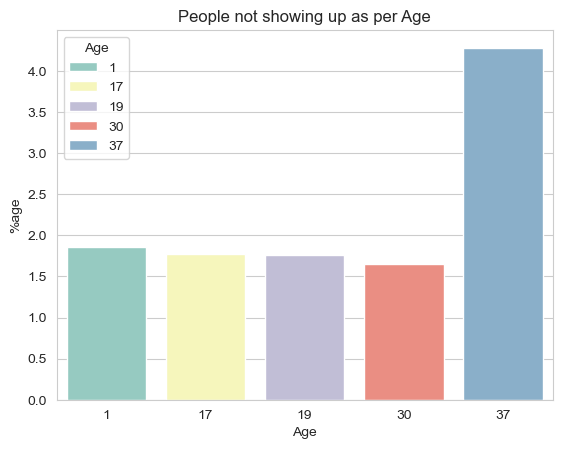

In [40]:
print(no_show_age.head())
sns.barplot(data = no_show_age.head(), x = 'Age', y = '%age', hue = 'Age', palette = 'Set3')
plt.title('People not showing up as per Age')

#### Neighbourhood and Show Column

In [41]:
df.groupby('Neighbourhood').Show.count().reset_index(name = 'Counts').sort_values(
    by = 'Counts', ascending = False).head()

,Neighbourhood,Counts
38,JARDIM CAMBURI,7717
43,MARIA ORTIZ,5805
59,RESISTÊNCIA,4431
39,JARDIM DA PENHA,3877
36,ITARARÉ,3514


In [42]:
neigh_no_show = df[no_show][['Neighbourhood']].value_counts().reset_index(
    name = 'Counts').sort_values(by = 'Counts', ascending = False).head()
neigh_show = df[show][['Neighbourhood']].value_counts().reset_index(
    name = 'Counts').sort_values(by = 'Counts', ascending = False).head()

    Neighbourhood  Counts
0  JARDIM CAMBURI    1465
1     MARIA ORTIZ    1219
2         ITARARÉ     923
3     RESISTÊNCIA     906
4          CENTRO     703


([0, 1, 2, 3, 4],
 [Text(0, 0, 'JARDIM CAMBURI'),
  Text(1, 0, 'MARIA ORTIZ'),
  Text(2, 0, 'ITARARÉ'),
  Text(3, 0, 'RESISTÊNCIA'),
  Text(4, 0, 'CENTRO')])

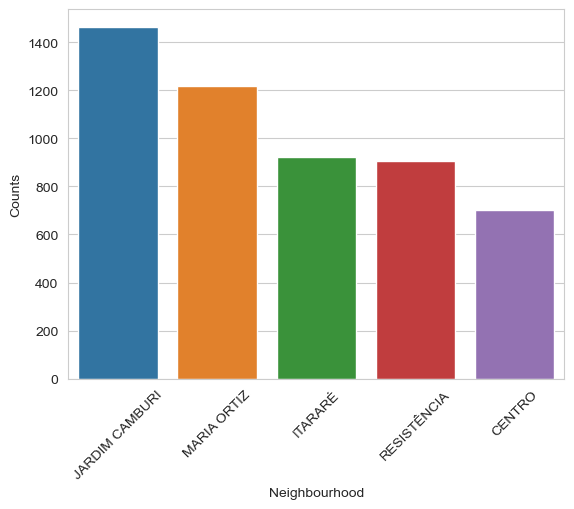

In [43]:
print(neigh_no_show)
sns.barplot(data = neigh_no_show, x = 'Neighbourhood', y = 'Counts', hue = 'Neighbourhood')
plt.xticks(rotation = 45)

     Neighbourhood  Counts
0   JARDIM CAMBURI    6252
1      MARIA ORTIZ    4586
2      RESISTÊNCIA    3525
3  JARDIM DA PENHA    3246
4     SANTA MARTHA    2635


([0, 1, 2, 3, 4],
 [Text(0, 0, 'JARDIM CAMBURI'),
  Text(1, 0, 'MARIA ORTIZ'),
  Text(2, 0, 'RESISTÊNCIA'),
  Text(3, 0, 'JARDIM DA PENHA'),
  Text(4, 0, 'SANTA MARTHA')])

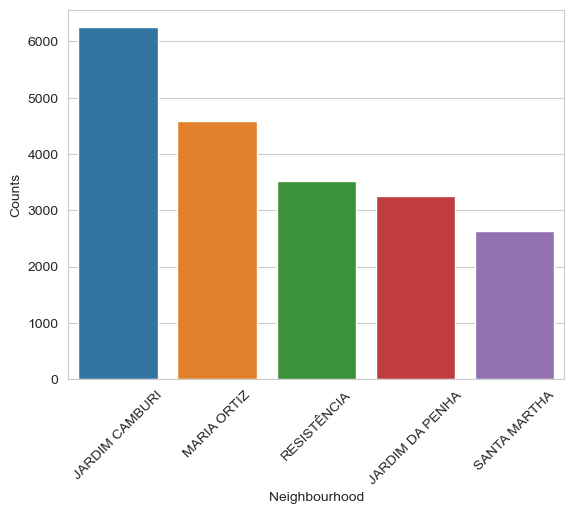

In [44]:
print(neigh_show)
sns.barplot(data = neigh_show, x = 'Neighbourhood', y = 'Counts', hue = 'Neighbourhood')
plt.xticks(rotation = 45)

#### Scholarship and Show Column

In [45]:
total = len(df)
summary = df.groupby(['Scholarship', 'Show']).size().reset_index(name='Count')
summary['%age'] = (summary.Count / total) * 100
summary

,Scholarship,Show,Count,%age
0,0,0,19741,17.860794
1,0,1,79925,72.312648
2,1,0,2578,2.332462
3,1,1,8283,7.494096


In [46]:
summary.groupby('Scholarship').Count.sum()

Scholarship
0    99666
1    10861
Name: Count, dtype: int64

In [47]:
ss_no_show = df[no_show][['Scholarship']].value_counts().reset_index(
    name = 'Counts').sort_values(by = 'Counts', ascending = False).head()
ss_show = df[show][['Scholarship']].value_counts().reset_index(
    name = 'Counts').sort_values(by = 'Counts', ascending = False).head()

   Scholarship  Counts
0            0   19741
1            1    2578


<Axes: xlabel='Scholarship', ylabel='Counts'>

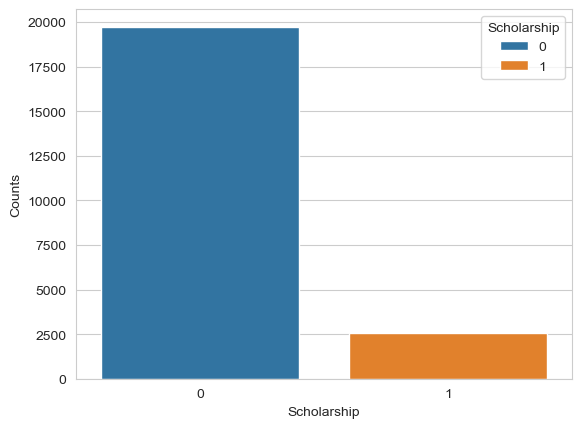

In [48]:
print(ss_no_show)
sns.barplot(data = ss_no_show, x = 'Scholarship', y = 'Counts', hue = 'Scholarship')

   Scholarship  Counts
0            0   79925
1            1    8283


<Axes: xlabel='Scholarship', ylabel='Counts'>

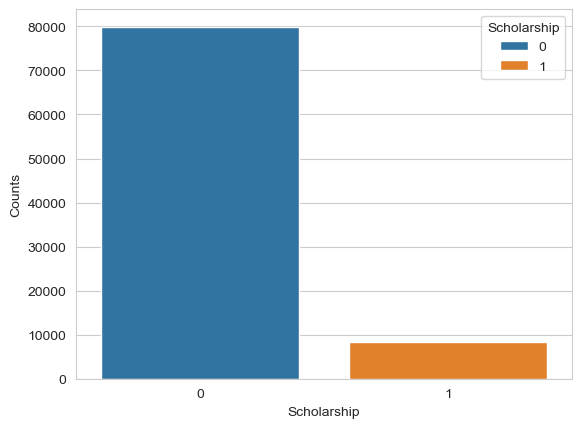

In [49]:
print(ss_show)
sns.barplot(data = ss_show, x = 'Scholarship', y = 'Counts', hue = 'Scholarship')

#### Hipertension, Diabetes, Alcoholism, Handcap and Show Columns

In [71]:
hipertension_shows_count = df.groupby(['Hipertension', 'Show']).size().reset_index(name = 'Counts')

total_by_hipertension = hipertension_shows_count.groupby('Hipertension')['Counts'].transform('sum')
hipertension_shows_count['Percent'] = (hipertension_shows_count['Counts'] / total_by_hipertension * 100).round(2)

hipertension_shows_count

,Hipertension,Show,Counts,Percent
0,0,0,18547,20.9
1,0,1,70179,79.1
2,1,0,3772,17.3
3,1,1,18029,82.7


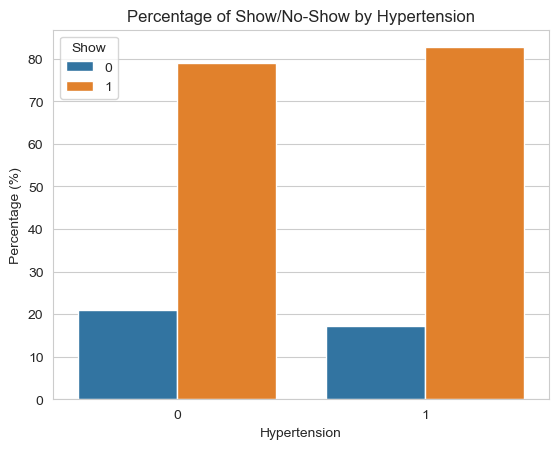

In [82]:
sns.barplot(data = hipertension_shows_count, x = 'Hipertension', y = 'Percent', hue = 'Show')
plt.title('Percentage of Show/No-Show by Hypertension')
plt.xlabel('Hypertension')
plt.ylabel('Percentage (%)')
plt.show()

In [73]:
diabetes_shows_count = df.groupby(['Diabetes', 'Show']).size().reset_index(name = 'Counts')

total_by_diabetes = diabetes_shows_count.groupby('Diabetes')['Counts'].transform('sum')
diabetes_shows_count['Percent'] = (diabetes_shows_count['Counts'] / total_by_diabetes * 100).round(2)

diabetes_shows_count

,Diabetes,Show,Counts,Percent
0,0,0,20889,20.36
1,0,1,81695,79.64
2,1,0,1430,18.00
3,1,1,6513,82.00


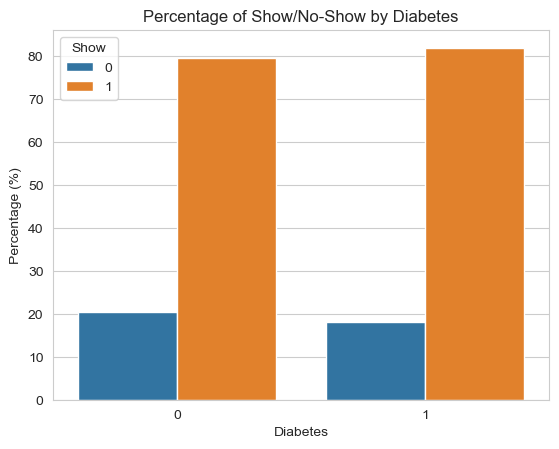

In [83]:
sns.barplot(data = diabetes_shows_count, x = 'Diabetes', y='Percent', hue='Show')
plt.title('Percentage of Show/No-Show by Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Percentage (%)')
plt.show()

In [76]:
alcoholism_shows_count = df.groupby(['Alcoholism', 'Show']).size().reset_index(name = 'Counts')

total_by_alcoholism = alcoholism_shows_count.groupby('Alcoholism')['Counts'].transform('sum')
alcoholism_shows_count['Percent'] = (alcoholism_shows_count['Counts'] / total_by_alcoholism * 100).round(2)

alcoholism_shows_count

,Alcoholism,Show,Counts,Percent
0,0,0,21642,20.19
1,0,1,85525,79.81
2,1,0,677,20.15
3,1,1,2683,79.85


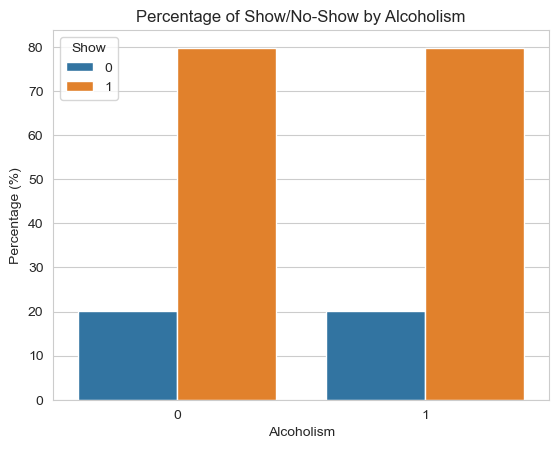

In [81]:
sns.barplot(data = alcoholism_shows_count, x = 'Alcoholism', y='Percent', hue='Show')
plt.title('Percentage of Show/No-Show by Alcoholism')
plt.xlabel('Alcoholism')
plt.ylabel('Percentage (%)')
plt.show()

In [78]:
handcap_shows_count = df.groupby(['Handcap', 'Show']).size().reset_index(name = 'Counts')

total_by_handcap = handcap_shows_count.groupby('Handcap')['Counts'].transform('sum')
handcap_shows_count['Percent'] = (handcap_shows_count['Counts'] / total_by_handcap * 100).round(2)

handcap_shows_count

,Handcap,Show,Counts,Percent
0,0,0,21912,20.24
1,0,1,86374,79.76
2,1,0,366,17.92
3,1,1,1676,82.08
4,2,0,37,20.22
5,2,1,146,79.78
6,3,0,3,23.08
7,3,1,10,76.92
8,4,0,1,33.33
9,4,1,2,66.67


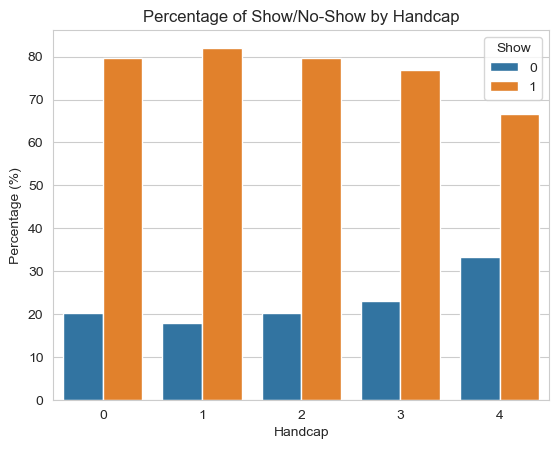

In [84]:
sns.barplot(data = handcap_shows_count, x = 'Handcap', y='Percent', hue='Show')
plt.title('Percentage of Show/No-Show by Handcap')
plt.xlabel('Handcap')
plt.ylabel('Percentage (%)')
plt.show()

#### SMS_received and Show Columns

In [89]:
sr_show_counts = df.groupby(['SMS_received', 'Show']).size().reset_index(name = 'Counts')

total_by_sms = sr_show_counts.groupby('SMS_received')['Counts'].transform('sum')
sr_show_counts['Percent'] = (sr_show_counts['Counts'] / total_by_sms * 100).round(2)

sr_show_counts

,SMS_received,Show,Counts,Percent
0,0,0,12535,16.70
1,0,1,62510,83.30
2,1,0,9784,27.57
3,1,1,25698,72.43


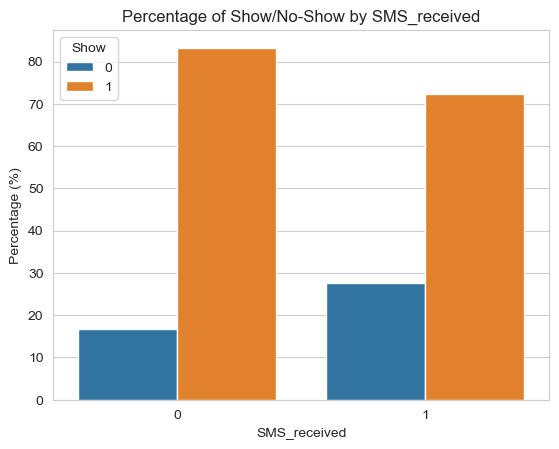

In [90]:
sns.barplot(data = sr_show_counts, x = 'SMS_received', y='Percent', hue='Show')
plt.title('Percentage of Show/No-Show by SMS_received')
plt.xlabel('SMS_received')
plt.ylabel('Percentage (%)')
plt.show()

#### days_until_appointment and Show Columns

In [96]:
df.days_until_appointment.value_counts().sort_values(ascending = False).reset_index(name = 'Count')

,days_until_appointment,Count
0,0,38563
1,2,6725
2,4,5290
3,1,5213
4,7,4906
...,...,...
126,-6,1
127,132,1
128,117,1
129,146,1


In [106]:
df_valid = df[df['days_until_appointment'] >= 0].copy()

bin_edges = [-1, 0, 4, 15, 179]
labels = ['Same Day', '1–4 Days', '5–15 Days', '16+ Days']

df_valid.loc[:, 'day_diff_bin'] = pd.cut(df_valid['days_until_appointment'], bins=bin_edges, labels=labels)

In [109]:
no_show = df_valid['Show'] == 0
df_noshow = df_valid[no_show]
df_noshow

noshow_prop = df_noshow['day_diff_bin'].value_counts(normalize=True) * 100
noshow_prop = noshow_prop.reindex(labels)

Proportion of No-Shows by Time Difference:
day_diff_bin
Same Day      8.03
1–4 Days     20.57
5–15 Days    32.93
16+ Days     38.47
Name: proportion, dtype: float64


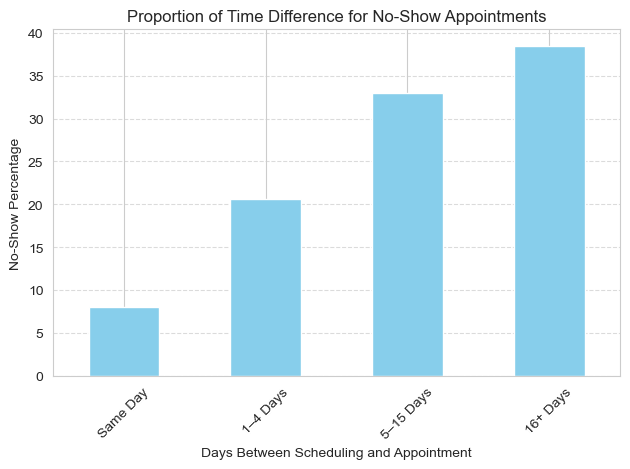

In [111]:
print("Proportion of No-Shows by Time Difference:")
print(noshow_prop.round(2))

noshow_prop.plot(kind='bar', color='skyblue')
plt.title('Proportion of Time Difference for No-Show Appointments')
plt.xlabel('Days Between Scheduling and Appointment')
plt.ylabel('No-Show Percentage')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusion
1.  Percentage of patients who didn't show up for their appointment is 20.19%.
2.  Monday's have recorded the highest no's. of appointements schedulinag.
3.  The percentage of females missing their appointment is nearly two times the number of males. So females are more likely to miss their appointment.
4.  There is no clear relation between the age and whether the patients show up or not but younger patients are more likely to miss their appointments.
5.  Jardim Camburi and Maria Ortiz neighbourhood's have the highest no. of patients missing their appointments.
6.  It seems that patients with scholarships are actually more likely to miss their appointment.
7.  A strange finding here suggests that patients who received an SMS are more likely to miss their appointment !!
8.  It appears that the longer the period between the scheduling and appointment the more likely the patient won't show up.

#### Analysis Shortcoming & Data Limitations

*   The data doesn't state the exact hour of the appointment which would have been very useful to try to find out which hours have the most missing appointments and which doesn't. It could also be very useful to know the difference between scheduling and the appointment since many of the scheduling are on the same day.
*   The data doesn't state if any day is a vacation or not which can indicate if people tend to miss their appointments more on working days.
*   The age column had a negative value but according to the data creator, it means a baby not born yet (a pregnant woman).
*   When calculating the day difference between the scheduling and appointment days we had some negative value which makes no sense and might mean that the records of questions have wrong data.
